# 02 – Preprocessing Pipeline
Konvertering av WAV → mel-spektrogram, normalisering, datasplitting (stratified train/val/test).

In [ ]:
# --- 1. Importer ---
import os
import numpy as np
import matplotlib.pyplot as plt
import librosa
import pickle
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm

In [ ]:
# --- 2. Stier og hyperparametre ---
DRIVE_DIR  = Path("/content/drive/MyDrive/IRMAS")
DATA_DIR   = DRIVE_DIR / "IRMAS-TrainingData"
OUT_DIR    = DRIVE_DIR / "processed"
OUT_DIR.mkdir(parents=True, exist_ok=True)

SR         = 22050
N_MELS     = 128
N_FFT      = 2048
HOP_LENGTH = 512
DURATION   = 3        # sekunder
TARGET_LEN = SR * DURATION

print("Data-mappe  :", DATA_DIR)
print("Output-mappe:", OUT_DIR)
print(f"SR={SR}, N_MELS={N_MELS}, N_FFT={N_FFT}, HOP_LENGTH={HOP_LENGTH}")

Data-mappe  : /content/drive/MyDrive/IRMAS/IRMAS-TrainingData
Output-mappe: /content/drive/MyDrive/IRMAS/processed
SR=22050, N_MELS=128, N_FFT=2048, HOP_LENGTH=512


In [ ]:
!wget -O "/content/drive/MyDrive/IRMAS/IRMAS-TrainingData.zip" "https://zenodo.org/records/1290750/files/IRMAS-TrainingData.zip?download=1"

--2026-04-16 15:08:03--  https://zenodo.org/records/1290750/files/IRMAS-TrainingData.zip?download=1
Resolving zenodo.org (zenodo.org)... 137.138.52.235, 188.184.103.118, 188.185.48.75, ...
Connecting to zenodo.org (zenodo.org)|137.138.52.235|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3181049879 (3.0G) [application/octet-stream]
Saving to: ‘/content/drive/MyDrive/IRMAS/IRMAS-TrainingData.zip’

/content/drive/MyDr 100%[===================>]   2.96G  23.5MB/s    in 11m 42s 

2026-04-16 15:19:45 (4.32 MB/s) - ‘/content/drive/MyDrive/IRMAS/IRMAS-TrainingData.zip’ saved [3181049879/3181049879]



In [ ]:
import zipfile
from pathlib import Path

with zipfile.ZipFile("/content/drive/MyDrive/IRMAS/IRMAS-TrainingData.zip", "r") as z:
    z.extractall("/content/drive/MyDrive/IRMAS/")
print("Ferdig!")

Ferdig!


In [ ]:
# --- 3. Preprocessing-funksjon ---
def wav_to_melspec(path):
    """
    Laster inn WAV-fil og returnerer normalisert
    mel-spektrogram som numpy array (128 x T x 1).
    """
    y, _ = librosa.load(path, sr=SR, mono=True)

    # Pad eller truncate til eksakt 3 sekunder
    if len(y) < TARGET_LEN:
        y = np.pad(y, (0, TARGET_LEN - len(y)))
    else:
        y = y[:TARGET_LEN]

    # Mel-spektrogram
    S    = librosa.feature.melspectrogram(
               y=y, sr=SR, n_mels=N_MELS,
               n_fft=N_FFT, hop_length=HOP_LENGTH
           )

    # Konverter til desibel-skala
    S_db = librosa.power_to_db(S, ref=np.max)

    # Min-max normalisering til [0, 1]
    S_min, S_max = S_db.min(), S_db.max()
    S_norm = (S_db - S_min) / (S_max - S_min + 1e-6)

    return S_norm  # shape: (128, ~130)

In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/IRMAS'))

['processed', 'IRMAS-TrainingData.zip', 'IRMAS-TrainingData']


In [ ]:
# --- 4. Bygg datasett ---
CLASSES = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
print(f"Klasser ({len(CLASSES)}): {CLASSES}")

X, y_labels = [], []
errors = []

for cls in CLASSES:
    wav_files = list((DATA_DIR / cls).glob("*.wav"))
    print(f"  {cls}: {len(wav_files)} klipp")
    for wav in tqdm(wav_files, desc=cls, leave=False):
        try:
            spec = wav_to_melspec(wav)
            X.append(spec)
            y_labels.append(cls)
        except Exception as e:
            errors.append((wav, str(e)))

print(f"\nFerdig. {len(X)} spektrogrammer generert.")
if errors:
    print(f"Feil på {len(errors)} filer: {errors[:3]}")

# Legg til kanal-dimensjon for CNN: (N, 128, T, 1)
X = np.array(X)[..., np.newaxis]
print(f"X shape: {X.shape}  dtype: {X.dtype}")

Klasser (11): ['cel', 'cla', 'flu', 'gac', 'gel', 'org', 'pia', 'sax', 'tru', 'vio', 'voi']
  cel: 388 klipp


  cla: 505 klipp


  flu: 451 klipp


  gac: 637 klipp


  gel: 760 klipp


...

  sax: 626 klipp


  tru: 577 klipp


  vio: 580 klipp


  voi: 778 klipp



Ferdig. 6705 spektrogrammer generert.
X shape: (6705, 128, 130, 1)  dtype: float32


In [ ]:
# --- 5. Label encoding ---
le = LabelEncoder()
y  = le.fit_transform(y_labels)

print("Klasser og indekser:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

Klasser og indekser:
  0 → cel
  1 → cla
  2 → flu
  3 → gac
  4 → gel
  5 → org
  6 → pia
  7 → sax
  8 → tru
  9 → vio
  10 → voi


In [ ]:
# --- 6. Stratified split: 70 / 15 / 15 ---
# Steg 1: skill ut test (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

# Steg 2: skill ut val (15% av total = ~17.6% av gjenværende)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, stratify=y_temp, random_state=42
)

print(f"Train : {len(X_train):5d} klipp  ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val   : {len(X_val):5d} klipp  ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test  : {len(X_test):5d} klipp  ({len(X_test)/len(X)*100:.1f}%)")

Train :  4695 klipp  (70.0%)
Val   :  1004 klipp  (15.0%)
Test  :  1006 klipp  (15.0%)


In [ ]:
# --- 7. Sjekk klassebalanse i hvert split ---
from collections import Counter

for navn, y_split in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    counts = Counter(y_split)
    print(f"\n{navn}:")
    for idx, cls in enumerate(le.classes_):
        print(f"  {cls}: {counts[idx]}")


Train:
  cel: 272
  cla: 353
  flu: 316
  gac: 446
  gel: 532
  org: 478
  pia: 505
  sax: 438
  tru: 404
  vio: 406
  voi: 545

Val:
  cel: 58
  cla: 76
  flu: 67
  gac: 95
  gel: 114
  org: 102
  pia: 108
  sax: 94
  tru: 87
  vio: 87
  voi: 116

Test:
  cel: 58
  cla: 76
  flu: 68
  gac: 96
  gel: 114
  org: 102
  pia: 108
  sax: 94
  tru: 86
  vio: 87
  voi: 117


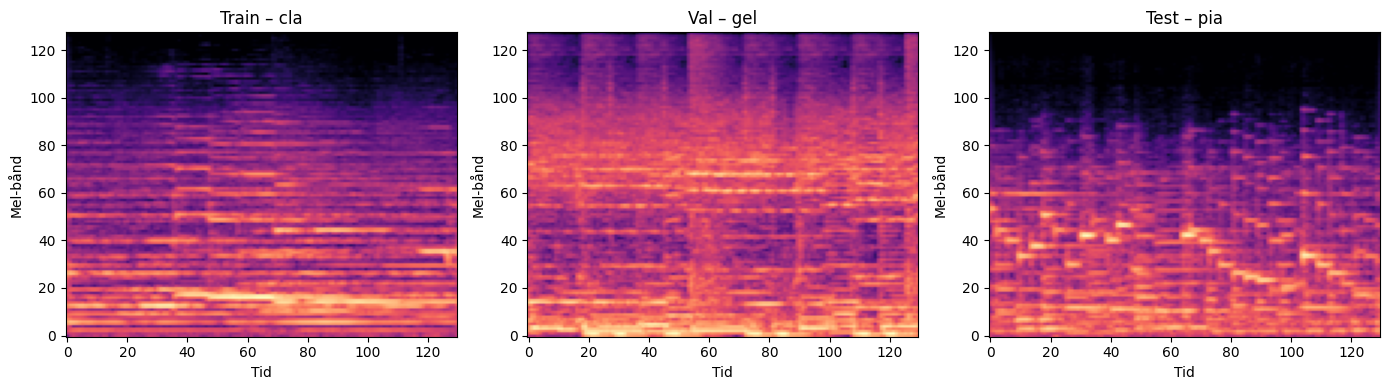

In [ ]:
# --- 8. Visualiser et tilfeldig spektrogram fra hvert split ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (navn, X_split, y_split) in zip(axes, [
    ("Train", X_train, y_train),
    ("Val",   X_val,   y_val),
    ("Test",  X_test,  y_test)
]):
    idx   = np.random.randint(len(X_split))
    spec  = X_split[idx, :, :, 0]
    label = le.classes_[y_split[idx]]
    ax.imshow(spec, aspect='auto', origin='lower', cmap='magma')
    ax.set_title(f"{navn} – {label}")
    ax.set_xlabel("Tid"); ax.set_ylabel("Mel-bånd")

plt.tight_layout()
plt.show()

In [ ]:
# --- 9. Lagre til disk ---
print("Lagrer til", OUT_DIR, "...")

np.save(OUT_DIR / "X_train.npy", X_train)
np.save(OUT_DIR / "y_train.npy", y_train)
np.save(OUT_DIR / "X_val.npy",   X_val)
np.save(OUT_DIR / "y_val.npy",   y_val)
np.save(OUT_DIR / "X_test.npy",  X_test)
np.save(OUT_DIR / "y_test.npy",  y_test)

with open(OUT_DIR / "label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

print("Ferdig! Lagrede filer:")
for f in sorted(OUT_DIR.iterdir()):
    size_mb = f.stat().st_size / 1e6
    print(f"  {f.name:25s}  {size_mb:.1f} MB")

Lagrer til /content/drive/MyDrive/IRMAS/processed ...
Ferdig! Lagrede filer:
  X_test.npy                 67.0 MB
  X_train.npy                312.5 MB
  X_val.npy                  66.8 MB
  label_encoder.pkl          0.0 MB
  y_test.npy                 0.0 MB
  y_train.npy                0.0 MB
  y_val.npy                  0.0 MB


In [ ]:
# --- 10. Oppsummering ---
print("=" * 45)
print("Preprocessing – oppsummering")
print("=" * 45)
print(f"Input shape : {X.shape[1:]}")
print(f"Klasser     : {list(le.classes_)}")
print(f"Train       : {len(X_train)}")
print(f"Val         : {len(X_val)}")
print(f"Test        : {len(X_test)}")
print()
print("Klar for modelltrening! Kjør 03_baseline_cnn.ipynb")

Preprocessing – oppsummering
Input shape : (128, 130, 1)
Klasser     : [np.str_('cel'), np.str_('cla'), np.str_('flu'), np.str_('gac'), np.str_('gel'), np.str_('org'), np.str_('pia'), np.str_('sax'), np.str_('tru'), np.str_('vio'), np.str_('voi')]
Train       : 4695
Val         : 1004
Test        : 1006

Klar for modelltrening! Kjør 03_baseline_cnn.ipynb
